# OrbitShield Vision - Treinamento ACV

## Contexto

Classificacao de imagens de sistemas espaciais em `satellite`, `rocket` e `space_shuttle`, simulando um sensor orbital com CNNs treinadas do zero.

## Historico

- Real-only com `space_station`: `69.70%`
- Real-only com `space_shuttle`: `66.17%`
- Decisao final: dataset hibrido com imagens reais da NASA e imagens sinteticas geradas em Python.
- Split final com separacao por `group_id` para impedir vazamento entre variantes sinteticas muito parecidas.

In [1]:
from pathlib import Path
import json, pandas as pd
from IPython.display import Image, display, Markdown
wd=Path.cwd()
ROOT=wd if (wd/"outputs").exists() else wd.parent
OUT=ROOT/"outputs"
model_df=pd.read_csv(OUT/"model_comparison.csv")
source_totals=pd.read_csv(OUT/"dataset_source_totals.csv")
split_summary=pd.read_csv(OUT/"dataset_split_summary.csv")
source_split=pd.read_csv(OUT/"dataset_source_split_summary.csv")
summary=json.loads((OUT/"training_summary.json").read_text(encoding="utf-8"))
model_df

,model_name,model_path,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,meets_reference_88,selected_best
0,SimpleCNN,C:\Users\enzoo\PycharmProjects\orbitshield-CV\...,0.227454,0.899628,0.900083,0.899709,0.899588,True,True
1,DeepCNN,C:\Users\enzoo\PycharmProjects\orbitshield-CV\...,0.388139,0.894052,0.894722,0.894091,0.893852,True,False


## Dataset final por classe

In [2]:
pivot=source_totals.pivot(index="class_name",columns="source_type",values="count").fillna(0).astype(int)
pivot["total"]=pivot.sum(axis=1)
pivot

source_type,real,synthetic,total
class_name,,,
rocket,299,900,1199
satellite,287,900,1187
space_shuttle,299,900,1199


## Pre-processamento

- auditoria e limpeza da base real;
- geracao de 900 imagens sinteticas por classe;
- resize para `128x128`;
- split estratificado `70/15/15`;
- separacao por `group_id` para manter familias sinteticas em um unico split;
- augmentation leve apenas no treino.

## Resultados finais

In [3]:
model_df

,model_name,model_path,test_loss,test_accuracy,precision_macro,recall_macro,f1_macro,meets_reference_88,selected_best
0,SimpleCNN,C:\Users\enzoo\PycharmProjects\orbitshield-CV\...,0.227454,0.899628,0.900083,0.899709,0.899588,True,True
1,DeepCNN,C:\Users\enzoo\PycharmProjects\orbitshield-CV\...,0.388139,0.894052,0.894722,0.894091,0.893852,True,False


## Comparacao com real-only

- Melhor real-only anterior: `69.70%`
- Melhor hibrido final: `89.96%`
- Ganho absoluto: `+20.26` pontos percentuais
- Meta ACV de `88%`: atingida

## Distribuicao por split

In [4]:
split_summary

,split,rocket,satellite,space_shuttle
0,test,180,178,180
1,train,839,831,839
2,val,180,178,180


## Distribuicao por origem e split

In [5]:
source_split

,split,rocket_real,rocket_synthetic,satellite_real,satellite_synthetic,space_shuttle_real,space_shuttle_synthetic
0,test,45,135,43,135,45,135
1,train,209,630,201,630,209,630
2,val,45,135,43,135,45,135


## Curvas de treinamento

### training_curves_simple_cnn.png

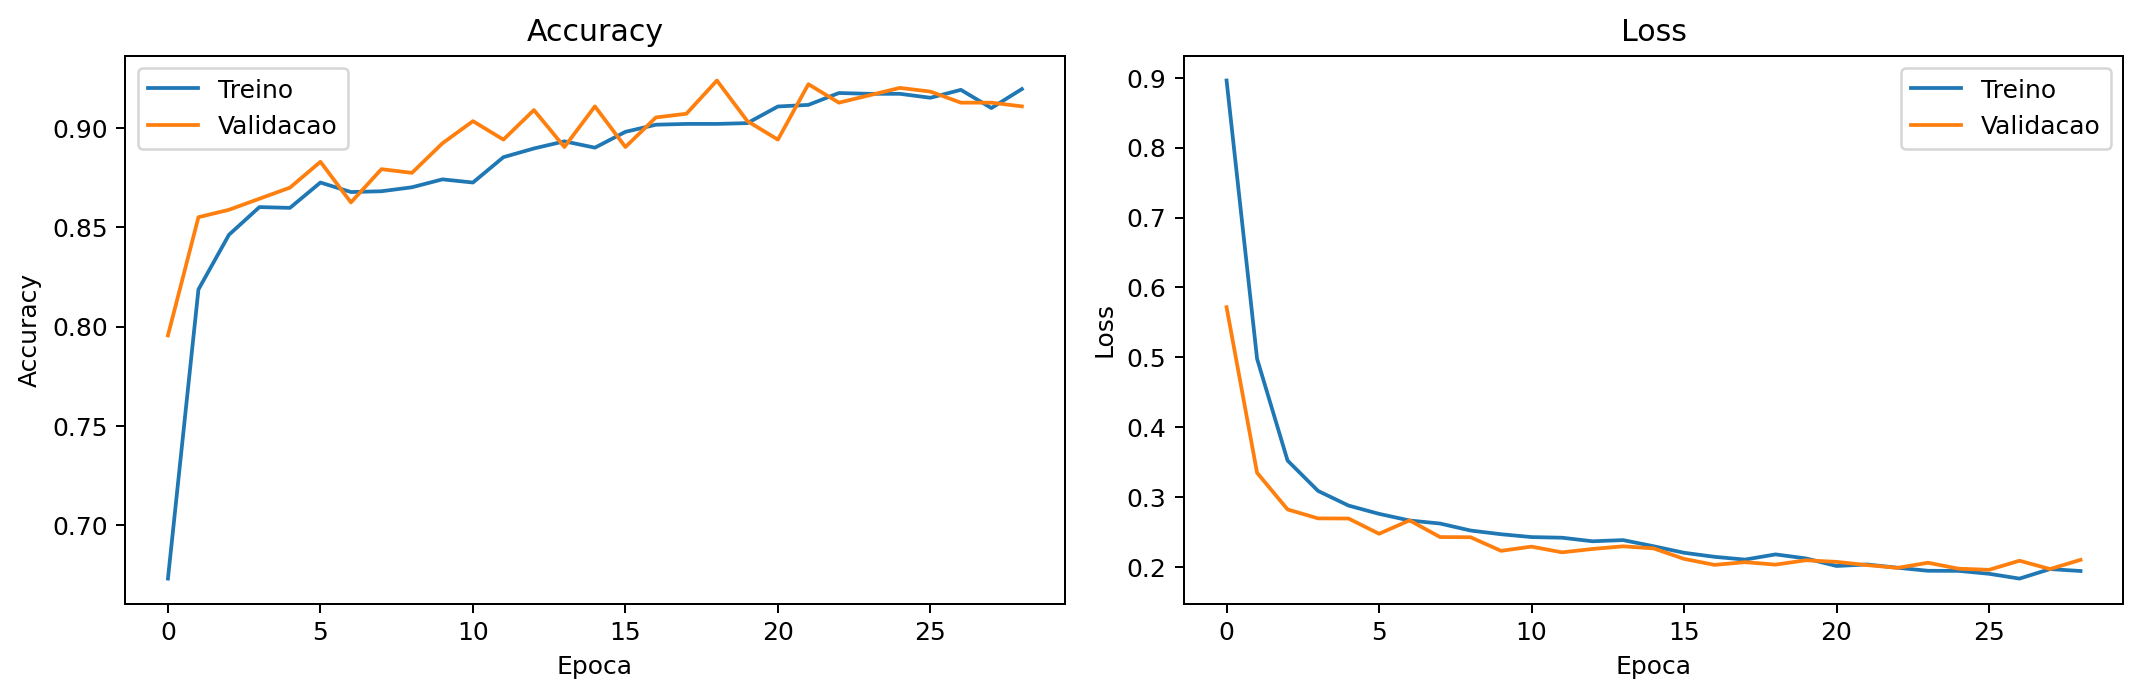

### training_curves_deep_cnn.png

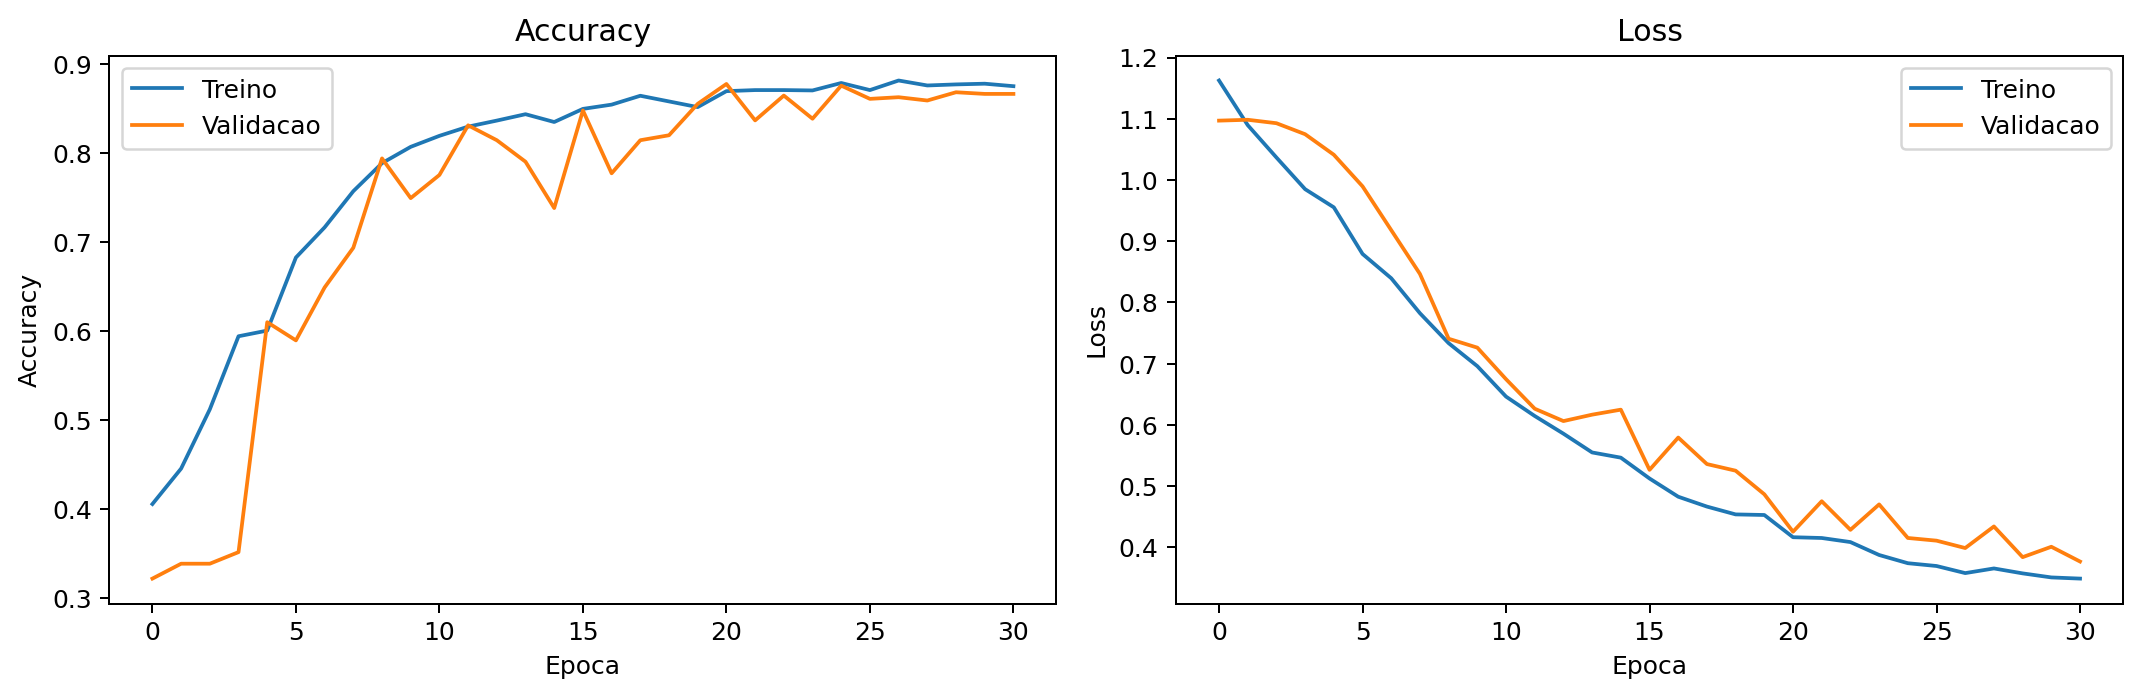

In [6]:
for n in ["training_curves_simple_cnn.png","training_curves_deep_cnn.png"]:
    display(Markdown(f"### {n}"))
    display(Image(filename=str(OUT/n)))

## Matrizes de confusao

### confusion_matrix_simple_cnn.png

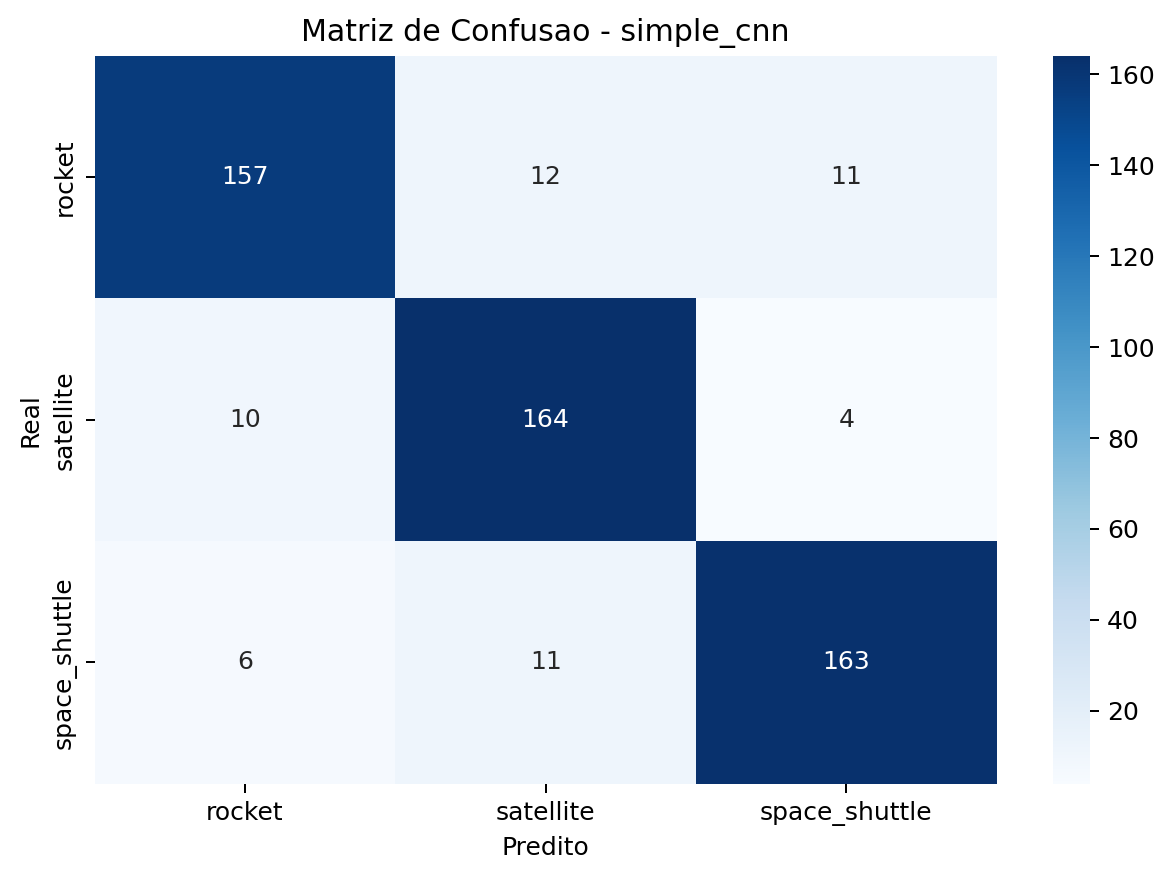

### confusion_matrix_deep_cnn.png

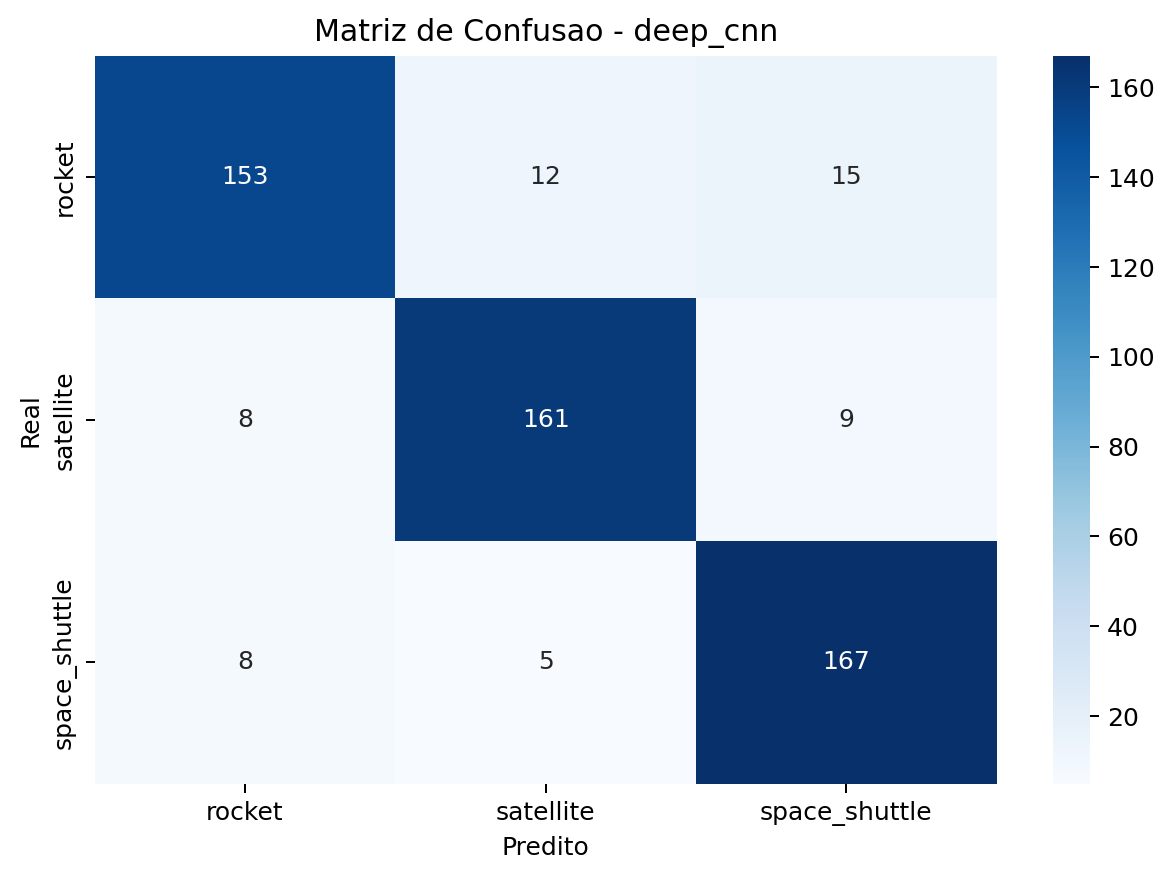

In [7]:
for n in ["confusion_matrix_simple_cnn.png","confusion_matrix_deep_cnn.png"]:
    display(Markdown(f"### {n}"))
    display(Image(filename=str(OUT/n)))

## Exemplos de acertos e erros

### correct_predictions.png

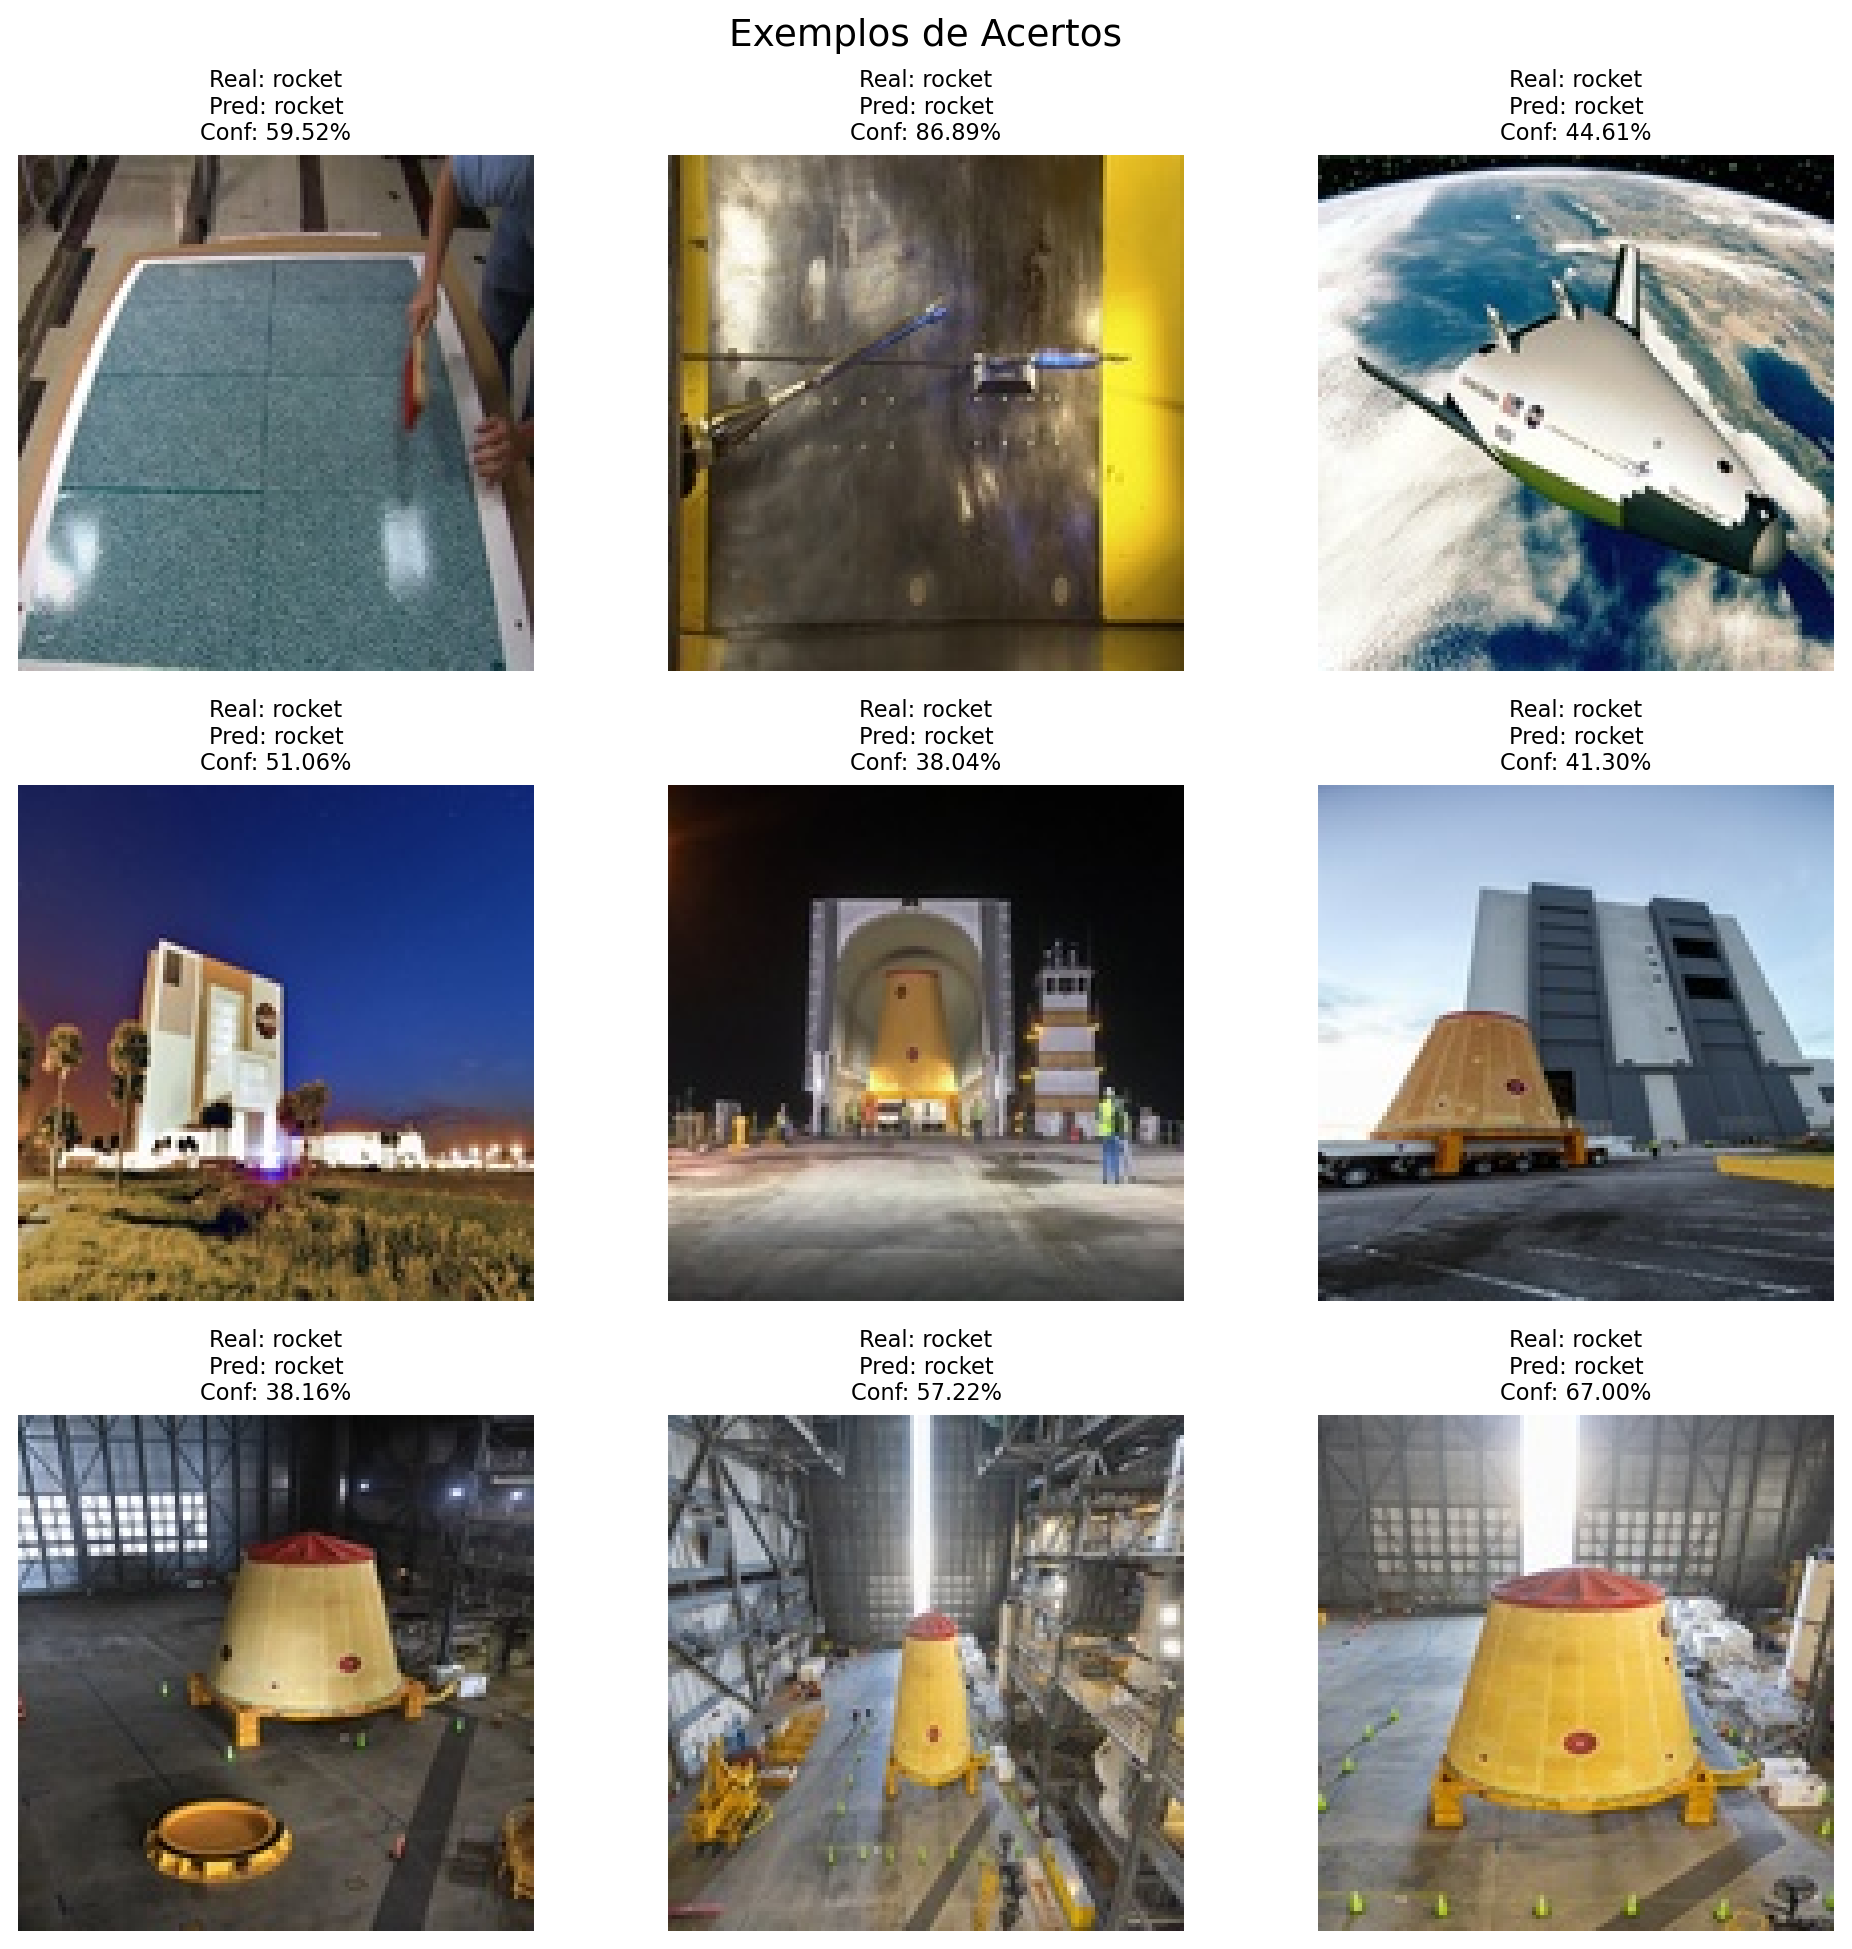

### wrong_predictions.png

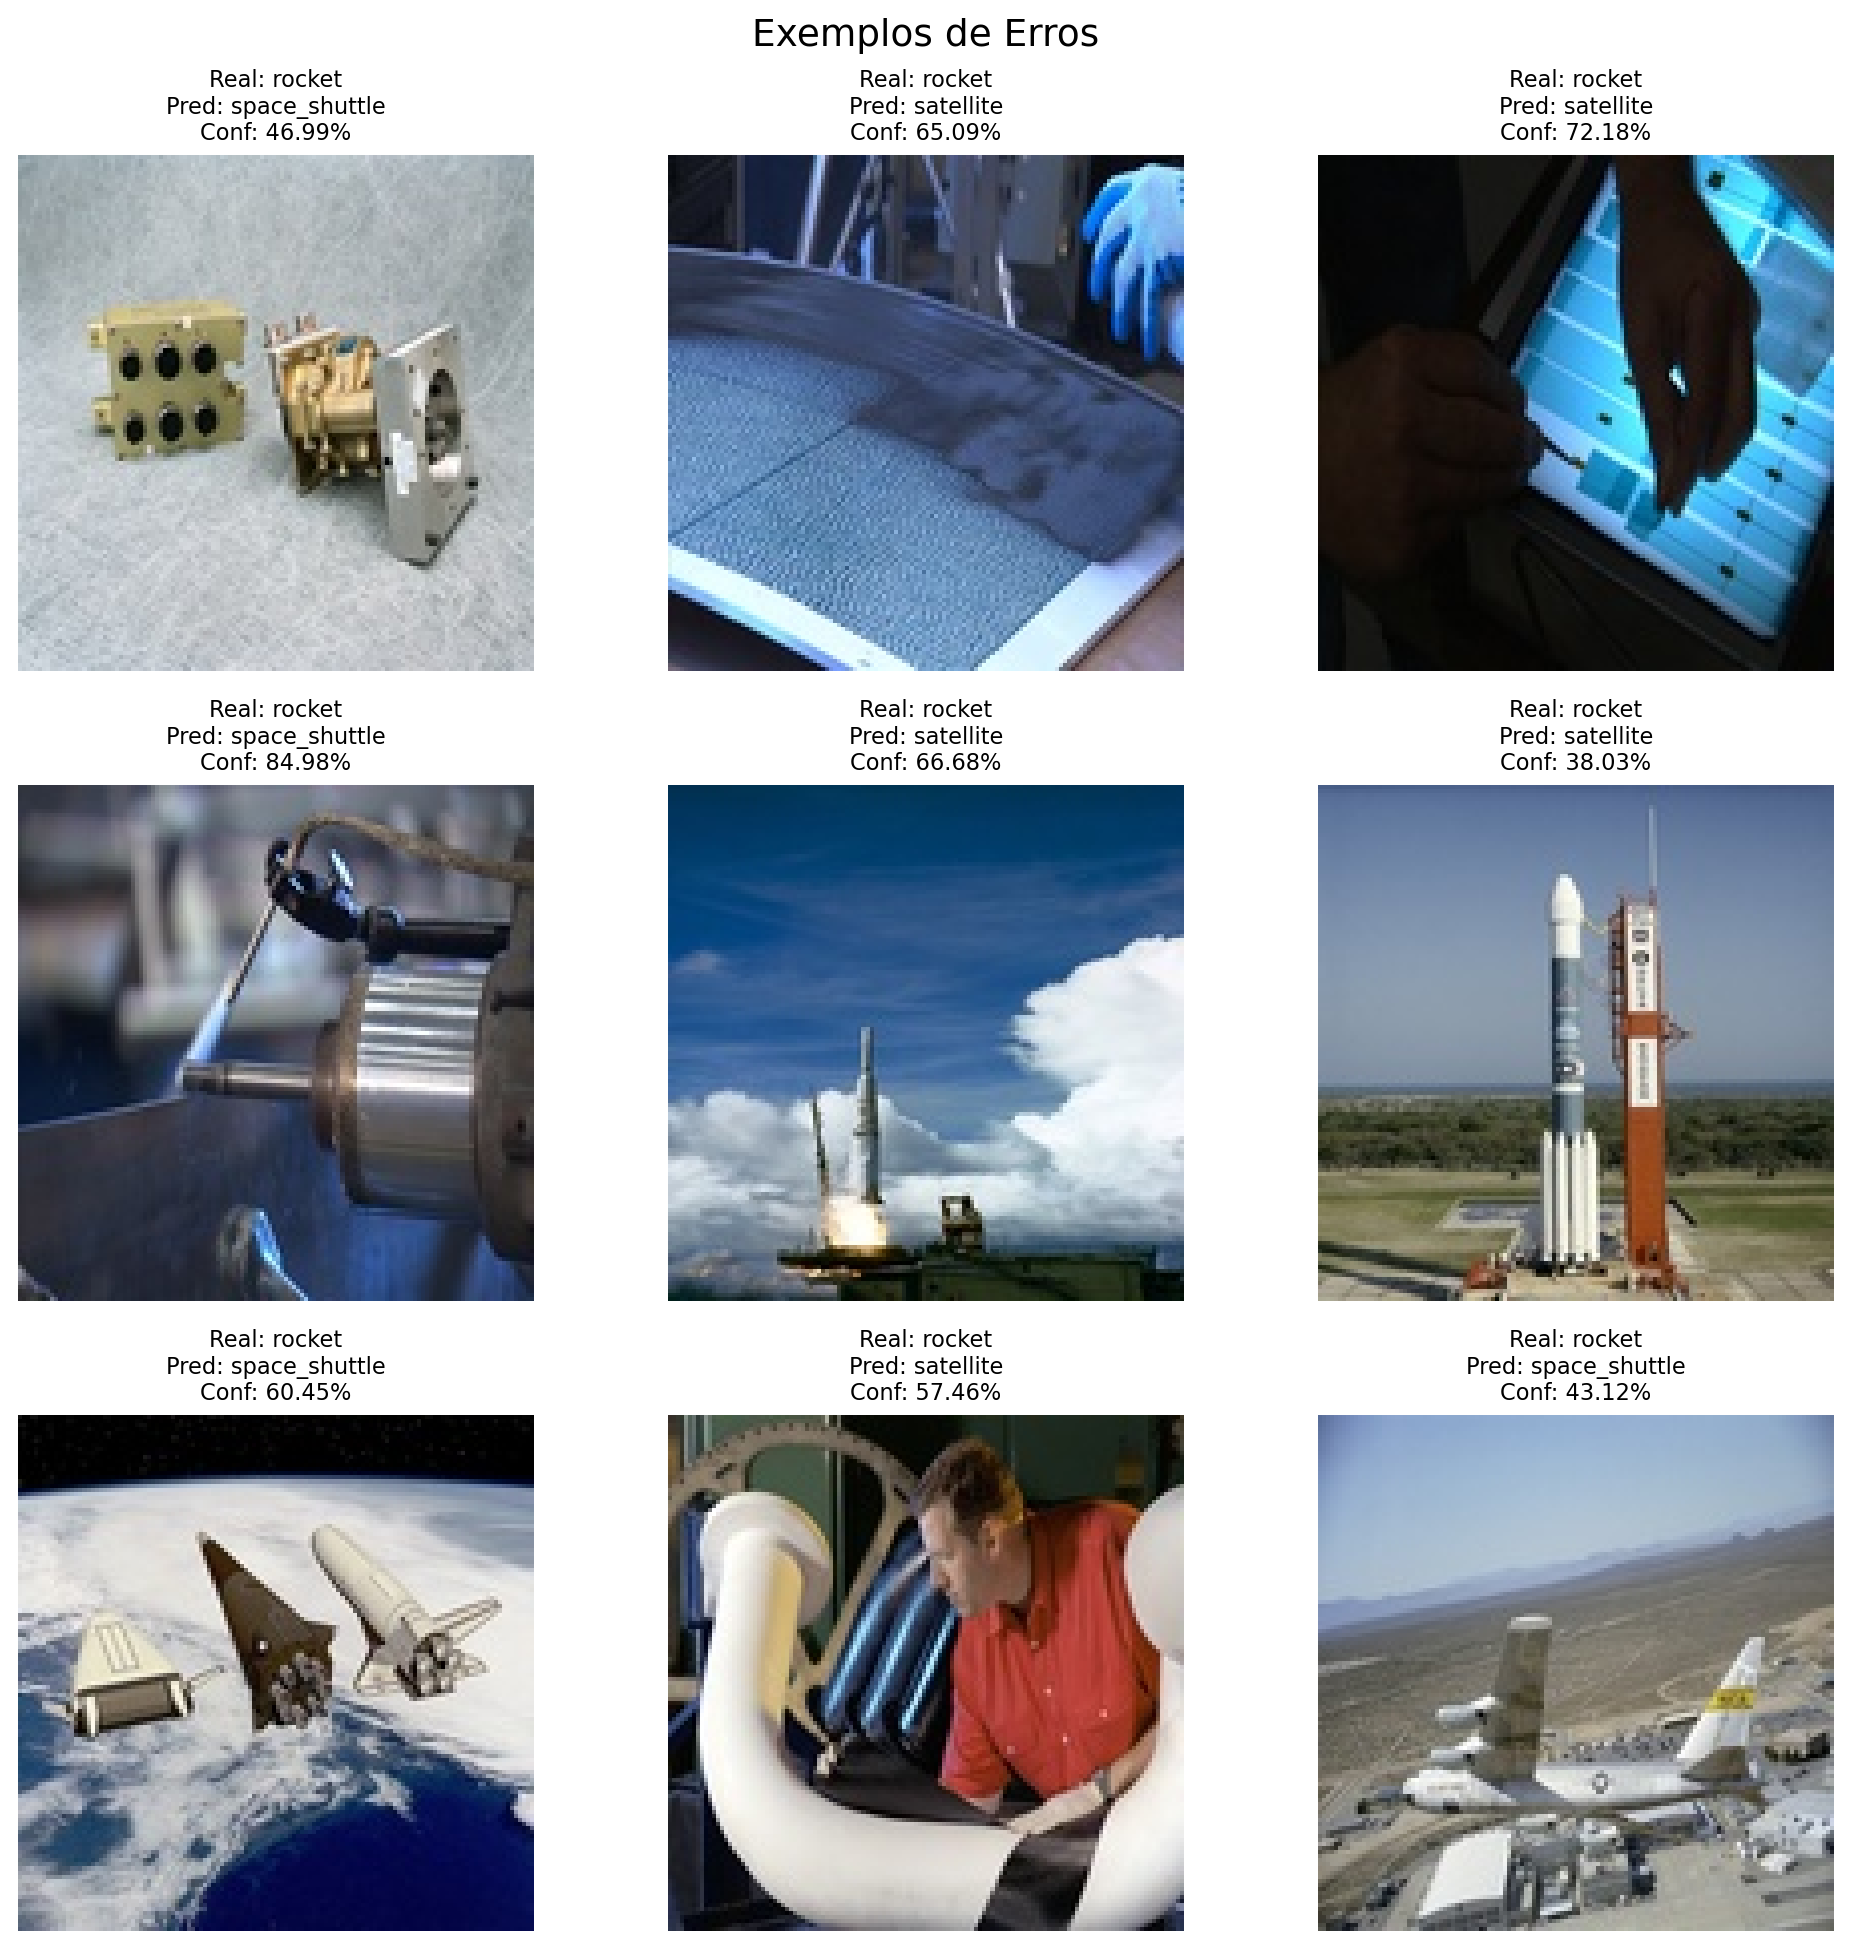

In [8]:
for n in ["correct_predictions.png","wrong_predictions.png"]:
    display(Markdown(f"### {n}"))
    display(Image(filename=str(OUT/n)))

## Conclusao tecnica

O dataset real-only da NASA nao foi suficiente para a meta desejada com CNNs do zero. O dataset hibrido com geracao sintetica mais separavel e split `group-aware` elevou a `SimpleCNN` para `89.96%` e a `DeepCNN` para `89.41%`, ultrapassando a referencia de `88%` sem usar modelos pre-treinados.